# Métodos Tradicionales — Backtest

Backtest de las 5 estrategias tradicionales sobre NVDA, MSFT y GOOGL (`datos/{TICKER}_dataset.csv`).

**Reglas comunes a los 13 métodos de la tesina:** capital inicial $10,000; costo 0.1 % por operación; Rf = 0; long-only, all-in/all-out (no hay cortos y el efectivo no rinde).

**Sin lookahead:** la posición decidida con datos hasta el cierre de `t` se evalúa con `Target_Retorno_1d[t]`, que ya es el retorno close-to-close de `t → t+1`. La misma vara se usará para los modelos de machine learning.

**Señales (Cap. 5):**

| Método | Posición |
|---|---|
| Buy & Hold | comprado todo el tramo |
| SMA Crossover | invertido mientras SMA_20 > SMA_50 |
| MACD | invertido mientras MACD > MACD_signal |
| RSI (Tabla 5) | entra al cruzar 30 al alza; sale al cruzar 70 a la baja |
| Mean Reversion (Tabla 7) | entra al tocar BB_lower; sale al tocar BB_upper |

**Métricas:** Retorno Total, Retorno Anualizado, Sharpe (principal), Volatilidad, Maximum Drawdown, Hit Ratio direccional (% de días en mercado que fueron al alza) y número de compras.

> Por ahora corre sobre toda la serie. Para la comparación final contra el ML se reportará también sobre el mismo tramo out-of-sample del walk-forward.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Parametros del backtest (identicos para los 13 metodos de la tesina)
CAPITAL_INICIAL = 10_000
COSTO = 0.001       # 0.1% por operacion (cada cambio de posicion)
DIAS_ANIO = 252     # factor de anualizacion
THETA = 0.002       # umbral ML (0.2%); referencia, no se usa en tradicionales

TICKERS = ['NVDA', 'MSFT', 'GOOGL']
DATA_DIR = Path('datos')   # carpeta relativa a la raiz del repo

In [2]:
def cargar(ticker):
    df = pd.read_csv(DATA_DIR / f'{ticker}_dataset.csv', parse_dates=['Date'])
    df = df.set_index('Date').sort_index()
    # La ultima fila no tiene dia siguiente real: si su target es NaN, se descarta
    df = df[df['Target_Retorno_1d'].notna()]
    return df

## Señales

Cada función devuelve una serie de posición 0/1 alineada al índice. SMA y MACD son de estado (invertido mientras se cumple la condición); RSI y Mean Reversion usan una máquina de estado long-only (entra con la señal de compra y mantiene hasta la de venta).

In [ ]:
def _maquina_estado(compra, venta):
    # Senales repetidas mientras ya se esta en ese estado se ignoran.
    c = compra.to_numpy()
    v = venta.to_numpy()
    pos = np.zeros(len(c), dtype=int)
    estado = 0
    for i in range(len(c)):
        if estado == 0 and c[i]:
            estado = 1
        elif estado == 1 and v[i]:
            estado = 0
        pos[i] = estado
    return pd.Series(pos, index=compra.index)


def senal_buy_hold(df):
    # Comprado todo el tramo (compra inicial y venta final las cobra el motor)
    return pd.Series(1, index=df.index)


def senal_sma(df):
    # Golden/death cross: invertido mientras SMA_20 > SMA_50
    return (df['SMA_20'] > df['SMA_50']).astype(int)


def senal_macd(df):
    # Invertido mientras el MACD esta por encima de su linea de senal
    return (df['MACD'] > df['MACD_signal']).astype(int)


def senal_rsi(df):
    # Tabla 5: compra al cruzar 30 al alza; venta al cruzar 70 a la baja
    rsi = df['RSI_14']
    prev = rsi.shift(1)
    compra = (prev < 30) & (rsi >= 30)
    venta = (prev > 70) & (rsi <= 70)
    return _maquina_estado(compra.fillna(False), venta.fillna(False))


def senal_mean_reversion(df):
    # Tabla 7: compra al tocar/caer bajo BB_lower; venta al tocar/superar BB_upper
    compra = df['Close'] <= df['BB_lower']
    venta = df['Close'] >= df['BB_upper']
    return _maquina_estado(compra, venta)


SENALES = {
    'Buy & Hold': senal_buy_hold,
    'SMA Crossover': senal_sma,
    'MACD': senal_macd,
    'RSI': senal_rsi,
    'Mean Reversion': senal_mean_reversion,
}

## Motor de backtest

In [4]:
def backtest(pos, ret, capital=CAPITAL_INICIAL, costo=COSTO):
    # Sin lookahead: pos[t] (decidida al cierre de t) gana ret[t],
    # donde ret = Target_Retorno_1d ya trae shift(-1) (retorno t -> t+1).
    pos = pos.astype(float)
    cambios = pos.diff().abs()
    cambios.iloc[0] = abs(pos.iloc[0])              # entrada inicial desde efectivo
    r = pos * ret - costo * cambios
    r.iloc[-1] = r.iloc[-1] - costo * pos.iloc[-1]  # liquidacion al cierre final
    equity = capital * (1.0 + r).cumprod()
    return r, equity

## Métricas

In [5]:
def metricas(r, equity, pos, ret):
    n = len(r)
    cap_final = equity.iloc[-1]
    ret_total = cap_final / CAPITAL_INICIAL - 1.0
    ret_anual = (cap_final / CAPITAL_INICIAL) ** (DIAS_ANIO / n) - 1.0
    sigma = r.std(ddof=1)
    sharpe = np.sqrt(DIAS_ANIO) * r.mean() / sigma if sigma > 0 else np.nan
    vol = sigma * np.sqrt(DIAS_ANIO)
    max_dd = (equity / equity.cummax() - 1.0).min()
    en_mercado = pos == 1
    hit = (ret[en_mercado] > 0).mean() if en_mercado.any() else np.nan
    n_compras = int((pos.diff() > 0).sum() + (pos.iloc[0] > 0))
    return {
        'Retorno Total': ret_total,
        'Retorno Anual': ret_anual,
        'Sharpe': sharpe,
        'Volatilidad': vol,
        'Max Drawdown': max_dd,
        'Hit Ratio': hit,
        '% en mercado': en_mercado.mean(),
        'N compras': n_compras,
    }

## Ejecución: 3 acciones × 5 métodos

In [6]:
filas = []
curvas = {}
for ticker in TICKERS:
    df = cargar(ticker)
    ret = df['Target_Retorno_1d']
    for nombre, fn in SENALES.items():
        pos = fn(df)
        r, equity = backtest(pos, ret)
        m = metricas(r, equity, pos, ret)
        m['Accion'] = ticker
        m['Metodo'] = nombre
        filas.append(m)
        curvas[(ticker, nombre)] = equity

cols = ['Retorno Total', 'Retorno Anual', 'Sharpe', 'Volatilidad',
        'Max Drawdown', 'Hit Ratio', '% en mercado', 'N compras']
resultados = pd.DataFrame(filas).set_index(['Accion', 'Metodo'])[cols]
resultados

Retorno Total  Retorno Anual    Sharpe  Volatilidad  \
Accion Metodo                                                                
NVDA   Buy & Hold         461.379428       0.515248  1.141738     0.453584   
       SMA Crossover       45.169909       0.296333  0.918310     0.347566   
       MACD                 4.556567       0.123159  0.528866     0.310630   
       RSI                 10.793777       0.181888  0.745187     0.274902   
       Mean Reversion      33.473819       0.270938  0.913652     0.317447   
MSFT   Buy & Hold          23.968200       0.243473  0.973951     0.257966   
       SMA Crossover        2.548798       0.089566  0.538969     0.194116   
       MACD                 0.045515       0.003019  0.103857     0.172708   
       RSI                  4.589869       0.123613  0.728693     0.182773   
       Mean Reversion       4.588575       0.123596  0.687544     0.197935   
GOOGL  Buy & Hold          21.141085       0.233394  0.894104     0.277652   
       SMA Crossover        5.645041       0.136849  0.722239     0.207183   
       MACD                 1.700591       0.069597  0.441521     0.194995   
       RSI                  2.290470       0.084003  0.530164     0.184066   
       Mean Reversion       6.947342       0.150711  0.824942     0.192615   

                       Max Drawdown  Hit Ratio  % en mercado  N compras  
Accion Metodo                                                            
NVDA   Buy & Hold         -0.663351   0.529965      1.000000          1  
       SMA Crossover      -0.638129   0.529980      0.667831         39  
       MACD               -0.584622   0.515861      0.516797        156  
       RSI                -0.475027   0.531365      0.364149         36  
       Mean Reversion     -0.485619   0.547651      0.400430         41  
MSFT   Buy & Hold         -0.371485   0.526471      1.000000          1  
       SMA Crossover      -0.440674   0.521653      0.676431         41  
       MACD               -0.404277   0.512297      0.513572        162  
       RSI                -0.264700   0.525517      0.389680         40  
       Mean Reversion     -0.353578   0.521063      0.414673         38  
GOOGL  Buy & Hold         -0.443200   0.532384      1.000000          1  
       SMA Crossover      -0.389751   0.529189      0.639882         38  
       MACD               -0.445172   0.515104      0.515990        159  
       RSI                -0.406421   0.540483      0.378393         37  
       Mean Reversion     -0.274385   0.550414      0.389143         40

In [7]:
# Vista con formato legible
fmt = {
    'Retorno Total': '{:.1%}', 'Retorno Anual': '{:.1%}',
    'Sharpe': '{:.2f}', 'Volatilidad': '{:.1%}',
    'Max Drawdown': '{:.1%}', 'Hit Ratio': '{:.1%}',
    '% en mercado': '{:.0%}', 'N compras': '{:.0f}',
}
resultados.style.format(fmt)

## Curvas de capital (escala logarítmica)

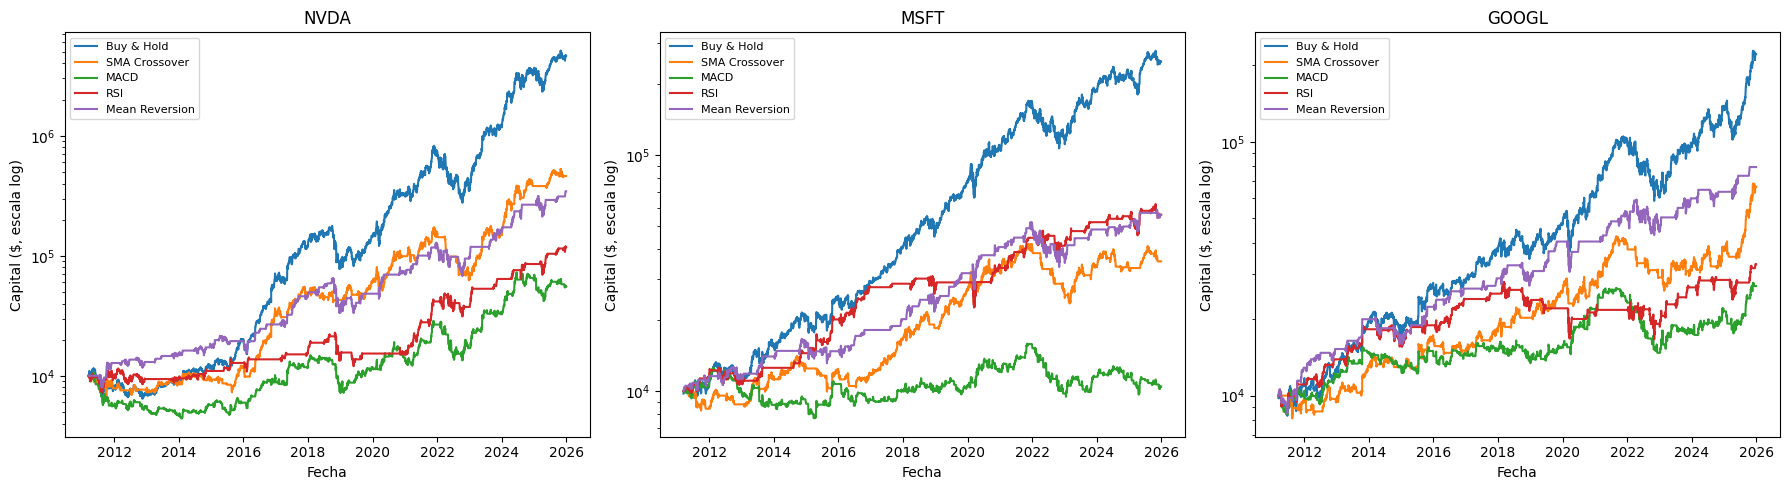

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, ticker in zip(axes, TICKERS):
    for nombre in SENALES:
        serie = curvas[(ticker, nombre)]
        ax.plot(serie.index, serie.values, label=nombre)
    ax.set_yscale('log')
    ax.set_title(ticker)
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Capital ($, escala log)')
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [9]:
resultados.to_csv('resultados_tradicionales.csv', encoding='utf-8')
print('Guardado: resultados_tradicionales.csv')

Guardado: resultados_tradicionales.csv
